# Attention-LSTM回归分析

## $\S1$ Configuration & Data Preparation

In [7]:
# Configuration
## Loading Packages
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Random Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Calculating Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

## Data Path
DATA_PATH = "./Raw_Data_5.xlsx"
Dependent_Variable = "USD_index_Close"

## Hyper Parameters
SCALE_Y      = False
MULTIPLE_Y = 1000
N_EPOCHS     = 50
PATIENCE     = 8
WEIGHT_DECAY = 1e-5
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20
TEST_RATIO  = 1.0 - TRAIN_RATIO - VAL_RATIO

BATCH_SIZE_LIST  = [64, 128]
LOOKBACK_LIST    = [10, 20, 40]
NUM_LAYERS_LIST  = [1, 2]
HIDDEN_SIZE_LIST = [32, 64]
DROPOUT_LIST     = [0.2, 0.4]
LR_LIST          = [1e-3, 1e-4]

Device: cuda


In [8]:
# Data Preparation
## Loading Data
Data = pd.read_excel(DATA_PATH, index_col="日期")
print("Data Size:", Data.shape)
print("Columns:", Data.columns)

X = Data.drop(columns=[Dependent_Variable]).values.astype(np.float32)
y = Data[[Dependent_Variable]].values.astype(np.float32) * MULTIPLE_Y

N = len(X)
n_train = int(N * TRAIN_RATIO)
n_val   = int(N * VAL_RATIO)
n_test  = N - n_train - n_val
print(f"训练集大小: {n_train}, 验证集大小: {n_val}, 测试集大小: {n_test}")

X_train = X[:n_train]
y_train = y[:n_train]

X_val   = X[n_train:n_train + n_val]
y_val   = y[n_train:n_train + n_val]

X_test  = X[n_train + n_val:]
y_test  = y[n_train + n_val:]

Data Size: (3456, 36)
Columns: Index(['USD_index_Close', 'USD_EUR_Open', 'USD_JPY_Open', 'USD_GBP_Open',
       'USD_CNY_Open', 'GOLD_Open', 'WTI_Open', 'US_10Y_Open', 'CN_10Y_Open',
       'UK_10Y_Open', 'JP_10Y_Open', 'GER_10Y_Open', 'VIX_Open',
       'US_index_Open', 'CN_index_Open', 'UK_index_Open', 'JP_index_Open',
       'GER_index_Open', 'US_10Y-CN_10Y_Open', 'US_10Y-GER_10Y_Open',
       'US_10Y-UK_10Y_Open', 'US_10Y-JP_10Y_Open', 'CN_10Y-GER_10Y_Open',
       'CN_10Y-UK_10Y_Open', 'CN_10Y-JP_10Y_Open', 'GER_10Y-UK_10Y_Open',
       'GER_10Y-JP_10Y_Open', 'UK_10Y-JP_10Y_Open', 'VIX_Delta',
       'USD_index_Close_Lag1', 'USD_index_Close_Lag4', 'USD_index_Close_Lag7',
       'USD_index_Close_Lag14', 'USD_index_Close_Std3', 'USD_index_Close_Std7',
       'USD_index_Close_Std14'],
      dtype='object')
训练集大小: 2073, 验证集大小: 691, 测试集大小: 692


In [9]:
### Data Scale
#### We will perform sacle dring Model selection and Final training


### Constructing Data Window
def create_sequences(X, y, seq_len):
    """
    X: (n_samples, n_features)
    y: (n_samples, 1)
    返回:
      X_seq: (N_seq, seq_len, n_features)
      y_seq: (N_seq,)
    """
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len])
    X_seq = np.stack(X_seq)             # (N_seq, seq_len, n_features)
    y_seq = np.stack(y_seq).squeeze()   # (N_seq,)
    return X_seq.astype(np.float32), y_seq.astype(np.float32)

class FXDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # 返回形状: X[idx] -> (seq_len, n_features), y[idx] -> 标量
        return self.X[idx], self.y[idx]

def make_dataloaders(X_train_seq, y_train_seq,
                     X_val_seq=None,   y_val_seq=None,
                     X_test_seq=None,  y_test_seq=None,
                     batch_size=64):
    train_dataset = FXDataset(X_train_seq, y_train_seq)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_loader  = None
    test_loader = None
    if X_val_seq is not None and y_val_seq is not None:
        val_dataset = FXDataset(X_val_seq, y_val_seq)
        val_loader  = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    if X_test_seq is not None and y_test_seq is not None:
        test_dataset = FXDataset(X_test_seq, y_test_seq)
        test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

## $\S2$ Model Selection, Training & Predicting

In [10]:
# Model Definition
class AttnLSTMRegressor(nn.Module):
    """
    架构: LSTM + 时间注意力
    输入: (batch, seq_len, input_size)
    输出: (batch, 1)
    """
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Attention: score_t = v^T tanh(W h_t)
        self.attn_W = nn.Linear(hidden_size, hidden_size)
        self.attn_v = nn.Linear(hidden_size, 1, bias=False)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)  # lstm_out: (batch, seq_len, hidden)
        # 计算注意力权重
        # (batch, seq_len, hidden) -> (batch, seq_len, hidden)
        scores = torch.tanh(self.attn_W(lstm_out))
        # -> (batch, seq_len, 1)
        scores = self.attn_v(scores)
        # -> (batch, seq_len)
        scores = scores.squeeze(-1)
        # 对时间维做 softmax
        attn_weights = torch.softmax(scores, dim=1)   # (batch, seq_len)

        # 加权求和得到 context
        # (batch, seq_len, hidden) * (batch, seq_len, 1)
        context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)  # (batch, hidden)

        out = self.fc(context)  # (batch, 1)
        return out


In [11]:
# Model Training
def train_model(model,
                train_loader,
                val_loader=None,
                n_epochs=50,
                lr=1e-3,
                weight_decay=1e-5,
                patience=8,
                device=device):

    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses   = []

    best_val_loss   = float("inf")
    best_state_dict = None
    wait = 0

    for epoch in range(1, n_epochs + 1):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0
        n_train        = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            # y_batch: (batch,) or (batch,1) -> (batch,1)
            y_batch = y_batch.to(device).view(-1, 1)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(X_batch)
            n_train        += len(X_batch)

        train_loss = train_loss_sum / n_train
        train_losses.append(train_loss)

        if val_loader is None:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f}")
            continue

        # ---- Validation ----
        model.eval()
        val_loss_sum = 0.0
        n_val        = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).view(-1, 1)
                y_pred  = model(X_batch)
                loss    = criterion(y_pred, y_batch)
                val_loss_sum += loss.item() * len(X_batch)
                n_val        += len(X_batch)

        val_loss = val_loss_sum / n_val
        val_losses.append(val_loss)

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        # ---- Early Stopping ----
        if val_loss < best_val_loss - 1e-8:
            best_val_loss   = val_loss
            best_state_dict = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}, best_val_loss={best_val_loss:.6f}")
                break

    # 恢复最优参数
    if val_loader is not None and best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, train_losses, val_losses, best_val_loss

In [12]:
# Model Selection
input_size = X_train.shape[1]

best_config = None
best_val_loss_overall = float("inf")

for lookback in LOOKBACK_LIST:
    print("=" * 80)
    print(f"Trying lookback = {lookback}")

    # 对给定 lookback，先在 Train 上 fit scaler_X，再对 Train/Val transform
    scaler_X_cv = StandardScaler()
    X_train_scaled_cv = scaler_X_cv.fit_transform(X_train)
    X_val_scaled_cv   = scaler_X_cv.transform(X_val)

    # y 是否做 StandardScaler
    if SCALE_Y:
        from sklearn.preprocessing import StandardScaler as _ScalerY
        scaler_y_cv = _ScalerY()
        y_train_scaled_cv = scaler_y_cv.fit_transform(y_train)
        y_val_scaled_cv   = scaler_y_cv.transform(y_val)
    else:
        y_train_scaled_cv = y_train
        y_val_scaled_cv   = y_val

    # 构造序列
    X_train_seq_cv, y_train_seq_cv = create_sequences(X_train_scaled_cv, y_train_scaled_cv, lookback)
    X_val_seq_cv,   y_val_seq_cv   = create_sequences(X_val_scaled_cv,   y_val_scaled_cv,   lookback)

    print("Train seq shape:", X_train_seq_cv.shape, y_train_seq_cv.shape)
    print("Val   seq shape:", X_val_seq_cv.shape,   y_val_seq_cv.shape)

    for hidden_size in HIDDEN_SIZE_LIST:
        for num_layers in NUM_LAYERS_LIST:
            for dropout in DROPOUT_LIST:
                for lr in LR_LIST:
                    for batch_size in BATCH_SIZE_LIST:

                        config = {
                            "lookback": lookback,
                            "hidden_size": hidden_size,
                            "num_layers": num_layers,
                            "dropout": dropout,
                            "lr": lr,
                            "batch_size": batch_size
                        }
                        print("\nConfig:", config)

                        train_loader_cv, val_loader_cv, _ = make_dataloaders(
                            X_train_seq_cv, y_train_seq_cv,
                            X_val_seq_cv,   y_val_seq_cv,
                            None, None,
                            batch_size=batch_size
                        )

                        model_cv = AttnLSTMRegressor(
                            input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout
                        )

                        model_cv, train_losses_cv, val_losses_cv, val_loss_cv = train_model(
                            model_cv,
                            train_loader_cv,
                            val_loader_cv,
                            n_epochs=N_EPOCHS,
                            lr=lr,
                            weight_decay=WEIGHT_DECAY,
                            patience=PATIENCE,
                            device=device
                        )

                        print(f"Config val_loss = {val_loss_cv:.6f}")

                        if val_loss_cv < best_val_loss_overall:
                            best_val_loss_overall = val_loss_cv
                            best_config = {
                                "lookback": lookback,
                                "hidden_size": hidden_size,
                                "num_layers": num_layers,
                                "dropout": dropout,
                                "lr": lr,
                                "batch_size": batch_size,
                                "scaler_X": scaler_X_cv,
                                "scaler_y": scaler_y_cv if SCALE_Y else None
                            }
                            print(">>> New best config:", best_config)

print("\n===== Best Config Overall =====")
print(best_config)
print("Best val_loss:", best_val_loss_overall)

Trying lookback = 10
Train seq shape: (2063, 10, 35) (2063,)
Val   seq shape: (681, 10, 35) (681,)

Config: {'lookback': 10, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64}
Epoch 001 | train_loss=27.424389 | val_loss=14.589784
Epoch 002 | train_loss=27.365530 | val_loss=14.588349
Epoch 003 | train_loss=27.307522 | val_loss=14.599890
Epoch 004 | train_loss=27.269721 | val_loss=14.613326
Epoch 005 | train_loss=27.217496 | val_loss=14.609165
Epoch 006 | train_loss=27.155440 | val_loss=14.613742
Epoch 007 | train_loss=27.067556 | val_loss=14.649507
Epoch 008 | train_loss=26.953485 | val_loss=14.643388
Epoch 009 | train_loss=26.778404 | val_loss=14.668189
Epoch 010 | train_loss=26.576363 | val_loss=14.718384
Early stopping at epoch 10, best_val_loss=14.588349
Config val_loss = 14.588349
>>> New best config: {'lookback': 10, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'scaler_X': StandardScaler(), 'scaler_y': None}

Co

In [13]:
# Final Training & Predicting
## 取出最优超参数
lookback   = best_config["lookback"]
hidden_size = best_config["hidden_size"]
num_layers  = best_config["num_layers"]
dropout     = best_config["dropout"]
lr          = best_config["lr"]
batch_size  = best_config["batch_size"]

print("\n>>> Final Training with best config:", best_config)

## 重新在 (Train+Val) 上 fit scaler
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)

scaler_X_final = StandardScaler()
X_train_val_scaled = scaler_X_final.fit_transform(X_train_val)
X_test_scaled      = scaler_X_final.transform(X_test)

if SCALE_Y:
    from sklearn.preprocessing import StandardScaler as _ScalerY
    scaler_y_final = _ScalerY()
    y_train_val_scaled = scaler_y_final.fit_transform(y_train_val)
    y_test_scaled      = scaler_y_final.transform(y_test)
else:
    y_train_val_scaled = y_train_val
    y_test_scaled      = y_test

## 构造序列
X_train_val_seq, y_train_val_seq = create_sequences(X_train_val_scaled, y_train_val_scaled, lookback)
X_test_seq,      y_test_seq      = create_sequences(X_test_scaled,      y_test_scaled,      lookback)

print("Train+Val seq shape:", X_train_val_seq.shape, y_train_val_seq.shape)
print("Test      seq shape:", X_test_seq.shape,      y_test_seq.shape)

train_loader_final, test_loader_final, _ = make_dataloaders(
    X_train_val_seq, y_train_val_seq,
    X_test_seq,      y_test_seq,
    None, None,
    batch_size=batch_size
)

model_final = AttnLSTMRegressor(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout
)

model_final, train_losses, test_losses, _ = train_model(
    model_final,
    train_loader_final,
    test_loader_final,
    n_epochs=N_EPOCHS,
    lr=lr,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=device
)



>>> Final Training with best config: {'lookback': 40, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'scaler_X': StandardScaler(), 'scaler_y': None}
Train+Val seq shape: (2724, 40, 35) (2724,)
Test      seq shape: (652, 40, 35) (652,)
Epoch 001 | train_loss=24.223269 | val_loss=21.692450
Epoch 002 | train_loss=24.138488 | val_loss=21.688647
Epoch 003 | train_loss=24.105245 | val_loss=21.682059
Epoch 004 | train_loss=24.085053 | val_loss=21.689139
Epoch 005 | train_loss=24.064896 | val_loss=21.729127
Epoch 006 | train_loss=24.035005 | val_loss=21.736619
Epoch 007 | train_loss=24.008390 | val_loss=21.728058
Epoch 008 | train_loss=23.954779 | val_loss=21.759591
Epoch 009 | train_loss=23.916120 | val_loss=21.836709
Epoch 010 | train_loss=23.872973 | val_loss=21.855184
Epoch 011 | train_loss=23.764236 | val_loss=21.824834
Early stopping at epoch 11, best_val_loss=21.682059


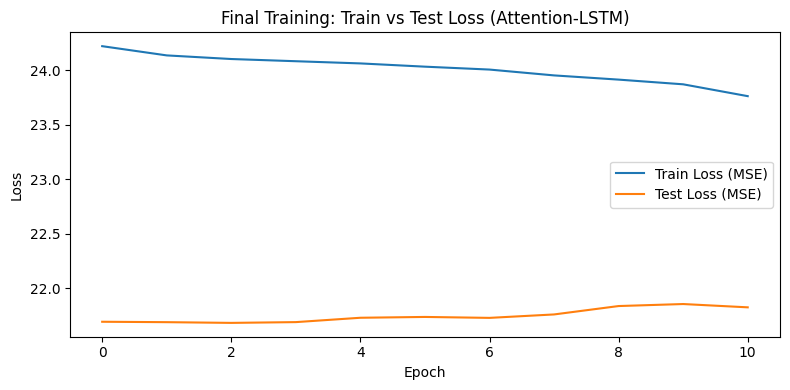

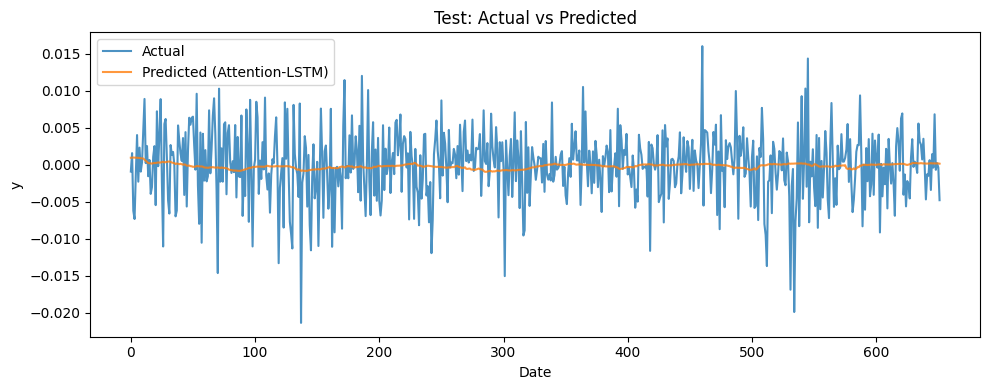


===== Test Performance (Attention-LSTM, Train+Val refit) =====
RMSE: 0.004672
MAE : 0.003532
R^2 : -0.005602
Direction Accuracy (sign of change): 0.4793


In [14]:
## Prediction
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss (MSE)")
plt.plot(test_losses,  label="Test Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Training: Train vs Test Loss (Attention-LSTM)")
plt.legend()
plt.tight_layout()
plt.show()

# 8.2 在 Test 上前向预测
model_final.eval()
y_true_list = []
y_pred_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_final:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1, 1)

        y_pred = model_final(X_batch)

        y_true_list.append(y_batch.cpu().numpy())
        y_pred_list.append(y_pred.cpu().numpy())

y_true = np.concatenate(y_true_list, axis=0).squeeze()
y_pred = np.concatenate(y_pred_list, axis=0).squeeze()

if SCALE_Y:
    y_true = best_config["scaler_y"].inverse_transform(y_true.reshape(-1, 1)).squeeze()
    y_pred = best_config["scaler_y"].inverse_transform(y_pred.reshape(-1, 1)).squeeze()

# 还原 MULTIPLE_Y
y_true = y_true / MULTIPLE_Y
y_pred = y_pred / MULTIPLE_Y

# 预测绘图
plt.figure(figsize=(10, 4))
plt.plot(y_true, label="Actual", alpha=0.8)
plt.plot(y_pred, label="Predicted (Attention-LSTM)", alpha=0.8)
plt.xlabel("Date")
plt.ylabel("y")
plt.title("Test: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# 8.3 指标
rmse = root_mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("\n===== Test Performance (Attention-LSTM, Train+Val refit) =====")
print(f"RMSE: {rmse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R^2 : {r2:.6f}")

# 方向准确率
sign_true = np.sign(np.diff(y_true))
sign_pred = np.sign(np.diff(y_pred))
if len(sign_true) == len(sign_pred) and len(sign_true) > 0:
    direction_acc = (sign_true == sign_pred).mean()
    print(f"Direction Accuracy (sign of change): {direction_acc:.4f}")

## $\S3$ Model Explanation